# Hypothesis Testing

## Research Question
Has three-point shooting usage significantly increased in the modern NBA compared to earlier seasons?

## Hypotheses

**Hypothesis 1 (Three-Point Share):**
- **H₀ (Null):** There is no significant difference in three-point scoring share between early and modern NBA seasons.
- **H₁ (Alternative):** Three-point scoring share is significantly higher in modern NBA seasons compared to early seasons.

**Hypothesis 2 (Three-Point Attempts):**
- **H₀ (Null):** There is no significant difference in three-point attempts (3PA) between early and modern NBA seasons.
- **H₁ (Alternative):** Three-point attempts are significantly higher in modern NBA seasons compared to early seasons.

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load dataset
df = pd.read_csv("DATA/processed/final_dataset.csv")

# Create season index
df["Season_num"] = range(len(df))

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (24, 8)

First few rows:


,Season,3PM,3PA,3P_percent,ThreePointShare,PTS_per_game,Pace,Season_num
0,1996-97,6.044828,16.79310,35.96207,18.735517,96.9,90.1,0
1,1997-98,4.403448,12.71379,34.37931,13.875862,95.6,90.3,1
2,1998-99,4.455172,13.16552,33.61724,14.546897,91.6,88.9,2
3,1999-00,4.837931,13.71724,35.28966,14.851720,97.5,93.1,3
4,2000-01,4.841379,13.70690,35.18276,15.277241,94.8,91.3,4


## 2. Splitting Into Early vs Modern Era

We split the dataset at Season_num = 12, which divides the 24 seasons into two equal halves:
- **Early era (1996–2008):** Seasons 0–11
- **Modern era (2008–2020):** Seasons 12–23

In [2]:
# Split into early vs modern era
early = df[df["Season_num"] < 12]
late = df[df["Season_num"] >= 12]

early_share = early["ThreePointShare"]
late_share = late["ThreePointShare"]
early_3pa = early["3PA"]
late_3pa = late["3PA"]

print(f"Early era seasons: {early['Season'].iloc[0]} to {early['Season'].iloc[-1]} ({len(early)} seasons)")
print(f"Modern era seasons: {late['Season'].iloc[0]} to {late['Season'].iloc[-1]} ({len(late)} seasons)")

Early era seasons: 1996-97 to 2007-08 (12 seasons)
Modern era seasons: 2008-09 to 2019-20 (12 seasons)


## 3. Hypothesis Test 1: Three-Point Share (ThreePointShare)

We perform an independent two-sample t-test to compare the mean ThreePointShare between the early and modern eras.

In [3]:
# Cohen's d effect size function
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2) / 2)

# Hypothesis Test 1: ThreePointShare (Welch's t-test)
t_stat, p_value = ttest_ind(early_share, late_share, equal_var=False)

print("=== Three-Point Share: Early vs Modern ===")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"\nEarly Mean: {early_share.mean():.4f}")
print(f"Late Mean:  {late_share.mean():.4f}")
print(f"\nSignificance level (alpha): 0.05")
if p_value < 0.05:
    print("Result: p < 0.05 → We REJECT H₀")
else:
    print("Result: p >= 0.05 → We FAIL to reject H₀")

print(f"\nEffect Size (Cohen's d): {cohens_d(late_share, early_share):.4f}")

=== Three-Point Share: Early vs Modern ===
T-Statistic: -4.8472
P-Value: 0.000273

Early Mean: 16.6040
Late Mean:  24.0745

Significance level (alpha): 0.05
Result: p < 0.05 → We REJECT H₀

Effect Size (Cohen's d): 1.9789


## 4. Hypothesis Test 2: Three-Point Attempts (3PA)

We apply the same independent t-test to compare the mean 3PA between the early and modern eras.

In [4]:
# Hypothesis Test 2: 3PA (Welch's t-test)
t_stat2, p_value2 = ttest_ind(early_3pa, late_3pa, equal_var=False)

print("=== Three-Point Attempts (3PA): Early vs Modern ===")
print(f"T-Statistic: {t_stat2:.4f}")
print(f"P-Value: {p_value2:.6f}")
print(f"\nEarly Mean: {early_3pa.mean():.4f}")
print(f"Late Mean:  {late_3pa.mean():.4f}")
print(f"\nSignificance level (alpha): 0.05")
if p_value2 < 0.05:
    print("Result: p < 0.05 → We REJECT H₀")
else:
    print("Result: p >= 0.05 → We FAIL to reject H₀")

print(f"\nEffect Size (Cohen's d): {cohens_d(late_3pa, early_3pa):.4f}")

=== Three-Point Attempts (3PA): Early vs Modern ===
T-Statistic: -4.9296
P-Value: 0.000286

Early Mean: 15.1024
Late Mean:  23.5642

Significance level (alpha): 0.05
Result: p < 0.05 → We REJECT H₀

Effect Size (Cohen's d): 2.0125


## 5. Visualization: Early vs Modern Era Comparison

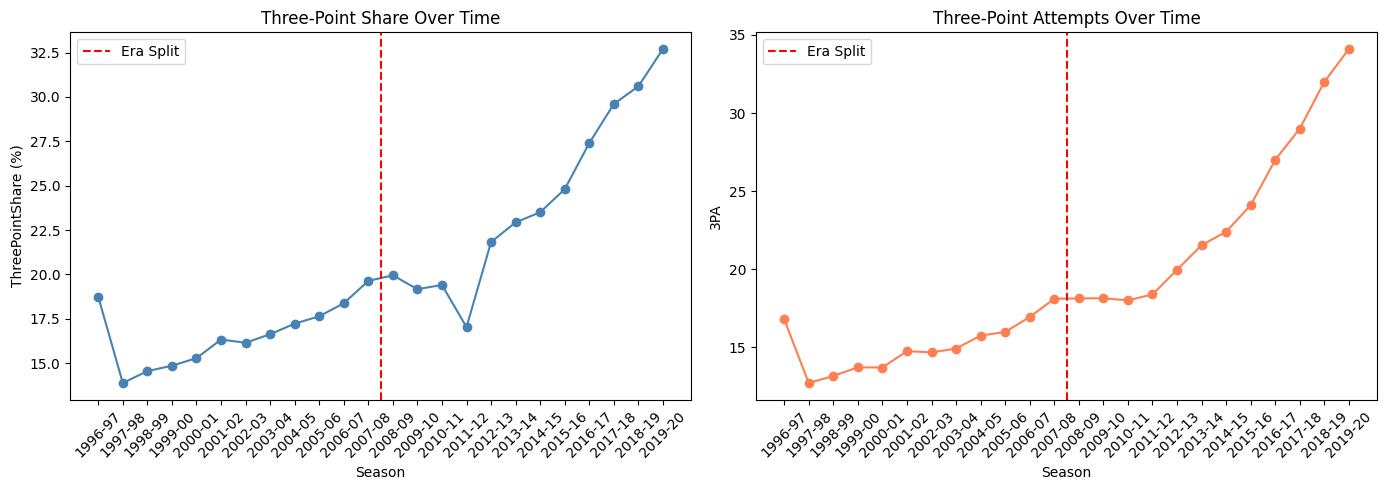

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart: ThreePointShare
axes[0].plot(df["Season"], df["ThreePointShare"], marker="o", color="steelblue")
axes[0].axvline(x=11.5, color="red", linestyle="--", label="Era Split")
axes[0].set_title("Three-Point Share Over Time")
axes[0].set_ylabel("ThreePointShare (%)")
axes[0].set_xlabel("Season")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# Line chart: 3PA
axes[1].plot(df["Season"], df["3PA"], marker="o", color="coral")
axes[1].axvline(x=11.5, color="red", linestyle="--", label="Era Split")
axes[1].set_title("Three-Point Attempts Over Time")
axes[1].set_ylabel("3PA")
axes[1].set_xlabel("Season")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

The results of both hypothesis tests strongly reject the null hypotheses, providing robust statistical evidence that three-point shooting has significantly increased in modern NBA.

Both the proportion of scoring from three-pointers (ThreePointShare) and the number of three-point attempts (3PA) show substantial and statistically significant growth.

The effect size further confirms that this is not only statistically significant but also practically meaningful.

These findings indicate a fundamental transformation in NBA offensive strategies, where three-point shooting has become a dominant component of scoring.